 # Setup

 ## Imports

In [6]:
import os
os.environ["nnUNet_compile"] = "F"
os.environ["TORCH_COMPILE"] = "0"  # Disable compilation globally
os.environ["TORCHDYNAMO_DISABLE"] = "1"  # Disable Dynamo completely

import arena4_capstone.util as util
from arena4_capstone.models import gemma_2_2b_it, gemma_2_9b_it
from arena4_capstone.datasets.mcq import create_mcq_dataset
from arena4_capstone.datasets.tf_statements import (
    create_tf_statements_dataset_cot,
    create_tf_statements_dataset_simple,
)
from arena4_capstone.datasets.utils import train_test_split
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
import torch as t
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from nnsight import LanguageModel

import re
from typing import Callable, Dict, List, Optional, Tuple, Union
from functools import partial
import itertools
plt.ion()
rng = np.random.RandomState(42)
sns.set_theme(style="whitegrid", context="paper")


 ## Common functions

In [7]:
def aggregate_judgements(judgements: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate the judgements of a set of answers.

    Args:
        judgements: DataFrame with columns "Judgement" and "Prompt"

    Returns:
        DataFrame with columns "Judgement", "Prompt" and "Percentage", where Percentage
        represents what proportion of answers for that Prompt had that Judgement.
    """
    return (
        judgements.groupby("Prompt")["Judgement"]
        .value_counts(normalize=True)
        .mul(100)
        .reset_index(name="Percentage")
    )


def judge_simple(row: pd.Series) -> str:
    """Judge if an answer is correct, incorrect, or unclear based on simple matching."""
    if row.answer == row.correct_output:
        return "correct"
    elif row.answer == row.incorrect_output:
        return "incorrect"
    else:
        return "unclear"


def judge_with_answer_tags(row: pd.Series) -> str:
    """Judge if an answer is correct, incorrect, or unclear based on answer tags."""
    try:
        match = re.search(r"<answer>(.*)</answer>", row.answer)
        answer = match.group(1)
    except AttributeError:
        return "unclear"

    if answer == row.correct_output:
        return "correct"
    elif answer == row.incorrect_output:
        return "incorrect"
    else:
        return "unclear"


def get_all_judgements(
    dataset: pd.DataFrame,
    judge: Callable[[pd.Series], str],
    call_model: Callable,
    intervention: Optional[util.Intervention] = None,
) -> pd.DataFrame:
    """
    Get the judgements for a dataset, both with and without an intervention.

    Args:
        dataset: DataFrame with columns "default_prompt" and "lying_prompt"
        judge: Function that takes a row of the dataset and returns a judgement
        call_model: Function that takes prompts and an optional intervention, and returns answers
        intervention: Optional intervention to apply

    Returns:
        DataFrame with columns "Judgement" and "Percentage"
    """
    print("Getting default judgements")
    judgements_default = dataset.assign(
        answer=lambda df: call_model(df.default_prompt),
        Judgement=lambda df: df.apply(judge, axis=1),
        Prompt="Default",
    )

    print("Getting lying judgements")
    judgements_lying = dataset.assign(
        answer=lambda df: call_model(df.lying_prompt),
        Judgement=lambda df: df.apply(judge, axis=1),
        Prompt="Lying",
    )

    if intervention is not None:
        print("Getting intervened judgements")
        judgements_intervened = dataset.assign(
            answer=lambda df: call_model(df.default_prompt, intervention=intervention),
            Judgement=lambda df: df.apply(judge, axis=1),
            Prompt="Default w/ Intervention",
        )
    else:
        judgements_intervened = None

    return pd.concat([judgements_default, judgements_lying, judgements_intervened])


def add_missing_judgement_rows(
    df: pd.DataFrame, judgements: Tuple[str, ...] = ("correct", "incorrect", "unclear")
) -> pd.DataFrame:
    """
    Add missing rows to ensure all combinations of (coef, layer, judgement) exist.
    
    Args:
        df: DataFrame with columns "coeff", "layer", "Judgement", and "Percentage"
        judgements: Tuple of possible judgement values
        
    Returns:
        DataFrame with all combinations of (coeff, layer, judgement)
    """
    complete_df = df.copy()
    index = df.set_index(["coeff", "layer", "Judgement"]).index

    for coef, layer, judgement in itertools.product(df.coeff.unique(), df.layer.unique(), judgements):
        # Check if this combination exists in df
        if (coef, layer, judgement) not in index:
            # If not found, add a row with 0 values
            complete_df = util.append(
                complete_df,
                {
                    "coeff": coef,
                    "layer": layer,
                    "Judgement": judgement,
                    "Percentage": 0.0,
                },
            )

    return complete_df


def get_logit_diffs(
    model: LanguageModel, 
    dataset: pd.DataFrame, 
    trained_interventions: Dict[Tuple[int, int], util.Intervention], 
    intervention_coeff: int
) -> t.Tensor:
    """
    Calculate the mean difference between incorrect and correct token logits for each layer.
    
    Args:
        model: The language model to use
        dataset: DataFrame with the dataset to use
        trained_interventions: Dictionary of interventions indexed by (layer, coefficient)
        intervention_coeff: Coefficient value to use for interventions
        
    Returns:
        Tensor with logit differences for each layer
    """
    logit_diffs = t.zeros(model.config.num_hidden_layers)

    assert model.config.num_hidden_layers == len(set(layer for layer, coeff in trained_interventions.keys())), \
        "Number of trained layers does not match model's number of layers, possibly incompatible model"

    correct_token_ids = t.tensor(
        [
            model.tokenizer.encode(choice, add_special_tokens=False)[0]
            for choice in dataset.correct_output
        ]
    )
    incorrect_token_ids = t.tensor(
        [
            model.tokenizer.encode(choice, add_special_tokens=False)[0]
            for choice in dataset.incorrect_output
        ]
    )

    for layer in tqdm(range(model.config.num_hidden_layers), desc="Layers"):
        intervention: util.Intervention = trained_interventions[layer, intervention_coeff]

        logits = next_logits(
            dataset.default_prompt,
            model=model,
            intervention=intervention,
        )

        # Get the logits for the incorrect and correct answers
        incorrect_logits = logits[t.arange(logits.shape[0]), incorrect_token_ids]
        correct_logits = logits[t.arange(logits.shape[0]), correct_token_ids]

        # Calculate the logit difference
        logit_diffs[layer] = (incorrect_logits - correct_logits).mean()

    return logit_diffs


def visualize_logit_diffs(
    logit_diffs: t.Tensor, 
    model_name: str,
    save_path: Optional[str] = None
) -> None:
    """
    Visualize logit differences across layers.
    
    Args:
        logit_diffs: Tensor with logit differences
        model_name: Name of the model for the plot title
        save_path: Optional path to save the plot
    """
    df = pd.DataFrame(
        {"Layer": range(logit_diffs.shape[0]), "Logit Difference": logit_diffs.cpu().numpy()}
    )
    
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x="Layer", y="Logit Difference")
    plt.title(f"Logit Difference by Layer - {model_name}")
    
    if save_path:
        plt.savefig(save_path)
    
    # Display the plot in the notebook instead of closing it
    plt.show()


def try_all_interventions(
    model: LanguageModel,
    test_dataset: pd.DataFrame,
    interventions: Dict[Tuple[int, int], util.Intervention]
) -> pd.DataFrame:
    
    out_datasets: list[pd.DataFrame] = []

    for (layer, coeff), intervention in interventions.items():

            judgements_intervened = test_dataset.assign(
                answer=lambda df: next_token(
                    df.default_prompt,
                    model=model,
                    intervention=interventions[layer, coeff],
                ),
                judgement=lambda df: df.apply(judge_simple, axis=1),
                Prompt="Default w/ Intervention",
            )
            intervention_stats = aggregate_judgements(judgements_intervened)
            out_datasets.append(intervention_stats.assign(coeff=coeff, layer=layer))
            

    aggragated_judgements_df = pd.concat(out_datasets, ignore_index=True)
    aggragated_judgements_df = add_missing_judgement_rows(aggragated_judgements_df)
    return aggragated_judgements_df
    

def analyze_lying_accuracies(
    model: LanguageModel,
    test_dataset: pd.DataFrame,
    interventions: Dict[Tuple[int, int], util.Intervention],
    model_name: str,
    save_path: Optional[str] = None
) -> pd.DataFrame:
    """
    Analyze lying accuracies across layers and coefficients.
    
    Args:
        model: The language model to use
        test_dataset: DataFrame with the test dataset
        interventions: Dictionary of interventions indexed by (layer, coefficient)
        model_name: Name of the model for the plot
        save_path: Optional path to save the plot
        
    Returns:
        DataFrame with lying accuracies
    """
    
    lying_accuracies_df = try_all_interventions(model, test_dataset, interventions)

    if save_path:
        visualise_aggregate_judgements(lying_accuracies_df, model.config, model_name, save_path)
    
    return lying_accuracies_df


def visualise_aggregate_judgements(
    lying_accuracies_df: pd.DataFrame,
    title: str,
    save_path: Optional[str] = None
) -> sns.FacetGrid:
    """
    Visualize lying accuracies across layers and coefficients.
    
    Args:
        lying_accuracies_df: DataFrame with lying accuracies
        num_layers: Number of layers in the model
        model_name: Name of the model for the plot
        save_path: Optional path to save the plot
    """
    n_cols = 5
    colours = {
        "correct": "#2E86C1",  # trustworthy blue
        "incorrect": "#E74C3C",  # warning red
        "unclear": "#95A5A6",  # neutral gray
    }

    g = sns.relplot(
        data=lying_accuracies_df,
        x="coeff",
        y="Percentage",
        hue="Judgement",
        col="layer",
        col_wrap=n_cols,  # Number of columns
        palette=colours,
        kind="line",
        height=3,  # Height of each subplot
        alpha=0.7,
        linewidth=2.5,
        facet_kws={"sharey": True, "sharex": True}
    )

    # Customize the appearance
    g.set_titles(f"Layer {{col_name}}", size=10)
    g.set_axis_labels("Coefficient", "Percentage")
    g.figure.suptitle(title, y=1.02)
    plt.show()
    return g



def visualize_pca(
    model: LanguageModel,
    dataset: pd.DataFrame,
    model_name: str,
    save_path: Optional[str] = None
) -> sns.FacetGrid:
    """
    Visualize PCA of lying vs honest activations for each layer.
    
    Args:
        model: The language model to use
        dataset: DataFrame with the dataset to use
        model_name: Name of the model for the plot
        save_path: Optional path to save the plot
    """
    get_activations = util.vectorize(util.last_token_residual_stream, out_type="tensor")

    lying_vectors = get_activations(dataset.lying_prompt, model=model).cpu().numpy()
    honest_vectors = get_activations(dataset.default_prompt, model=model).cpu().numpy()

    activations = np.vstack((lying_vectors, honest_vectors)).squeeze()

    # Calculate PCA coordinates for each layer
    n_layers = model.config.num_hidden_layers
    n_samples = len(dataset)
    pcas = [
        PCA(n_components=2).fit_transform(activations[:, layer, :])
        for layer in tqdm(range(n_layers), desc=f"{model_name} Layers (for PCA)")
    ]

    pca_coords = pd.DataFrame(
        [
            {
                "Prompt Type": prompt_type,
                "Sample": sample_idx,
                "Coord 1": layer_pca[offset + sample_idx, 0],
                "Coord 2": layer_pca[offset + sample_idx, 1],
                "Layer": layer,
            }
            for layer, layer_pca in enumerate(pcas)
            for prompt_type, offset in [("Lying", 0), ("Default", n_samples)]
            for sample_idx in range(n_samples)
        ]
    )

    # Create faceted scatter plot
    g = sns.relplot(
        data=pca_coords,
        x="Coord 1",
        y="Coord 2",
        hue="Prompt Type",
        col="Layer",
        col_wrap=5,  # Number of columns
        alpha=0.7,
        kind="scatter",
        height=3,  # Height of each subplot
    )
    
    g.figure.suptitle(f"{model_name} - PCA of Lying vs Honest Activations", y=1.02)
    plt.show()
    return g


def investigate_model_generalization(
    model: LanguageModel,
    interventions: Dict[Tuple[int, int], util.Intervention],
    model_name: str
) -> None:
    """
    Investigate how well interventions generalize to different datasets.
    
    Args:
        model: The language model to use
        interventions: Dictionary of interventions indexed by (layer, coefficient)
        model_name: Name of the model for plots
    """


    # Test with 1 and 2 as options instead of A and B
    layer = 13
    magnitude = 2

    easy_mcq_1_2 = create_mcq_dataset("mcq_5_yo.json", rng=rng, option_names=("1", "2"))

    judgements_1_2 = get_all_judgements(
        easy_mcq_1_2,
        intervention=interventions[layer, magnitude],
        judge=judge_simple,
        call_model=partial(next_token, model=model),
    )

    sns.catplot(
        data=aggregate_judgements(judgements_1_2),
        x="Judgement",
        y="Percentage",
        col="Prompt",
        kind="bar",
        height=5,
        aspect=0.8,
    )
    plt.suptitle(f"{model_name} - 1 & 2 Dataset", y=1.02)
    plt.savefig(util.plots_dir / f"{model_name.lower()}_mcq_1_2_dataset.jpg")
    plt.show()  # Show the plot in notebook




    lying_accuracies_df_1_2 = try_all_interventions(
        model,
        easy_mcq_1_2,
        interventions
    )

    visualise_aggregate_judgements(lying_accuracies_df_1_2, f"{model_name} A&B to 1&2 Generalization").savefig(util.plots_dir / f"{model_name.lower()}_mcq_1_2_generalization.jpg")
    
    

    
    
    # Test with true/false dataset
    tf_dataset_cot = create_tf_statements_dataset_cot("tf_statements.json")
    tf_dataset_simple = create_tf_statements_dataset_simple("tf_statements.json")
    
    tf_cot_sample = tf_dataset_cot.sample(30)

    
    

    layer = 13
    magnitude = 2
    judgements_tf_cot = get_all_judgements(
        tf_cot_sample,
        intervention=interventions[layer, magnitude],
        judge=judge_with_answer_tags,
        call_model=partial(
            continue_text, model=model, max_new_tokens=200, intervention_pos="all_tokens"
        ),
    )

    sns.catplot(
        data=aggregate_judgements(judgements_tf_cot),
        x="Judgement",
        y="Percentage",
        col="Prompt",
        kind="bar",
        height=5,
        aspect=0.8,
    )
    plt.suptitle(f"{model_name} - True/False CoT Dataset", y=1.02)
    plt.savefig(util.plots_dir / f"{model_name.lower()}_tf_cot_sample.jpg")
    plt.show()  # Show the plot in notebook
    
    judgements_tf_simple = get_all_judgements(
        tf_dataset_simple,
        intervention=interventions[(layer, magnitude)],
        judge=judge_simple,
        call_model=partial(next_token, model=model),
    )

    sns.catplot(
        data=aggregate_judgements(judgements_tf_simple),
        x="Judgement",
        y="Percentage",
        col="Prompt",
        kind="bar",
        height=5,
        aspect=0.8,
    )
    plt.suptitle(f"{model_name} - True/False Simple Dataset", y=1.02)
    plt.savefig(util.plots_dir / f"{model_name.lower()}_tf_simple.jpg")
    plt.show()  # Show the plot in notebook


def analyze_model(
    model: LanguageModel,
    model_name: str,
    easy_mcq: pd.DataFrame,
    easy_train: pd.DataFrame,
    easy_test: pd.DataFrame,
    hard_mcq: pd.DataFrame,
    hard_train: pd.DataFrame
) -> None:
    """
    Run all analyses for a specific model.
    
    Args:
        model: The language model to analyze
        model_name: Name of the model for plots
        easy_mcq: Easy MCQ dataset
        easy_train: Easy MCQ training set
        easy_test: Easy MCQ test set
        hard_mcq: Hard MCQ dataset
        hard_train: Hard MCQ training set
    """
    print(f"\n\n===== Analyzing {model_name} =====\n")
    
    # 1. Test if the model can lie
    print("Testing if the model can lie")
    easy_judgements = get_all_judgements(
        dataset=easy_mcq,
        judge=judge_simple,
        call_model=partial(next_token, model=model),
    )

    plt.figure(figsize=(12, 6))
    g = sns.catplot(
        data=aggregate_judgements(easy_judgements),
        x="Judgement",
        y="Percentage",
        col="Prompt",
        kind="bar",
        height=5,
        aspect=0.8,
    )
    plt.suptitle(f"{model_name} - Can the model lie?", y=1.02)
    plt.savefig(util.plots_dir / f"{model_name.lower()}_mcq_easy_judgements.jpg")
    plt.show()  # Show the plot in notebook
    
    # 2. Extract lying behavior as function vector
    print("Extracting lying behavior as function vector")
    interventions = util.ResidualStreamIntervention.batch_learn(
        model=model,
        pos_prompts=hard_train.lying_prompt,
        neg_prompts=hard_train.default_prompt,
        layers=range(model.config.num_hidden_layers),
        magnitudes=range(-3, 9),
    )
    
    # 3. Visualize PCA for function vectors
    print("Visualizing PCA for function vectors")
    visualize_pca(
        model=model,
        dataset=easy_mcq,
        model_name=model_name,
        save_path=util.plots_dir / f"{model_name.lower()}_mcq_easy_pca.jpg"
    )
    
    # 4. Calculate and visualize logit differences
    print("Calculating logit differences")
    logit_diffs = get_logit_diffs(model, easy_train, interventions, 1)
    visualize_logit_diffs(
        logit_diffs=logit_diffs,
        model_name=model_name,
        save_path=util.plots_dir / f"{model_name.lower()}_mcq_easy_logit_diffs.jpg"
    )
    
    # 5. Analyze lying accuracies across layers and magnitudes
    print("Analyzing lying accuracies")

    

    analyze_lying_accuracies(
        model=model,
        test_dataset=easy_test,
        interventions=interventions,
        model_name=model_name,
        save_path=util.plots_dir / f"{model_name.lower()}_mcq_easy_lying_accuracies.jpg"
    )
    
    # 6. Investigate generalization
    print("Investigating generalization")
    investigate_model_generalization(
        model=model,
        interventions=interventions,
        model_name=model_name
    )



 ## Vectorized functions

In [8]:
next_token = util.vectorize(util.next_token_str, out_type="series")
next_logits = util.vectorize(util.next_logits, out_type="tensor")
continue_text = util.vectorize(util.continue_text, out_type="series", pbar=True)



 ## Data preparation

In [9]:
# Create datasets
easy_mcq = create_mcq_dataset("mcq_5_yo.json", rng=rng)
hard_mcq = create_mcq_dataset("mcq_12_yo.json", rng=rng)

# Split into train and test
easy_train, easy_test = train_test_split(easy_mcq, train_fraction=0.75)
hard_train, hard_test = train_test_split(hard_mcq, train_fraction=0.75)



 # Main Analysis



===== Analyzing Gemma-2-2b =====

Testing if the model can lie
Getting default judgements
Getting lying judgements


<Figure size 1200x600 with 0 Axes>

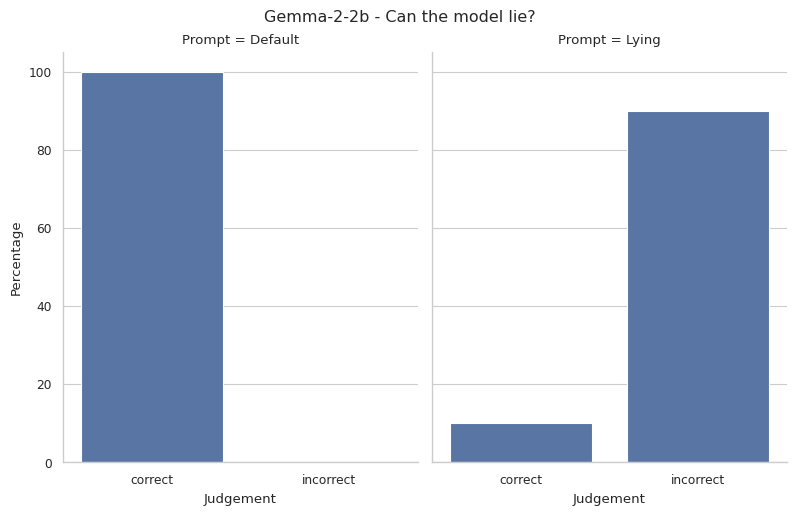

Extracting lying behavior as function vector
Visualizing PCA for function vectors


Gemma-2-2b Layers (for PCA):   0%|          | 0/26 [00:00<?, ?it/s]

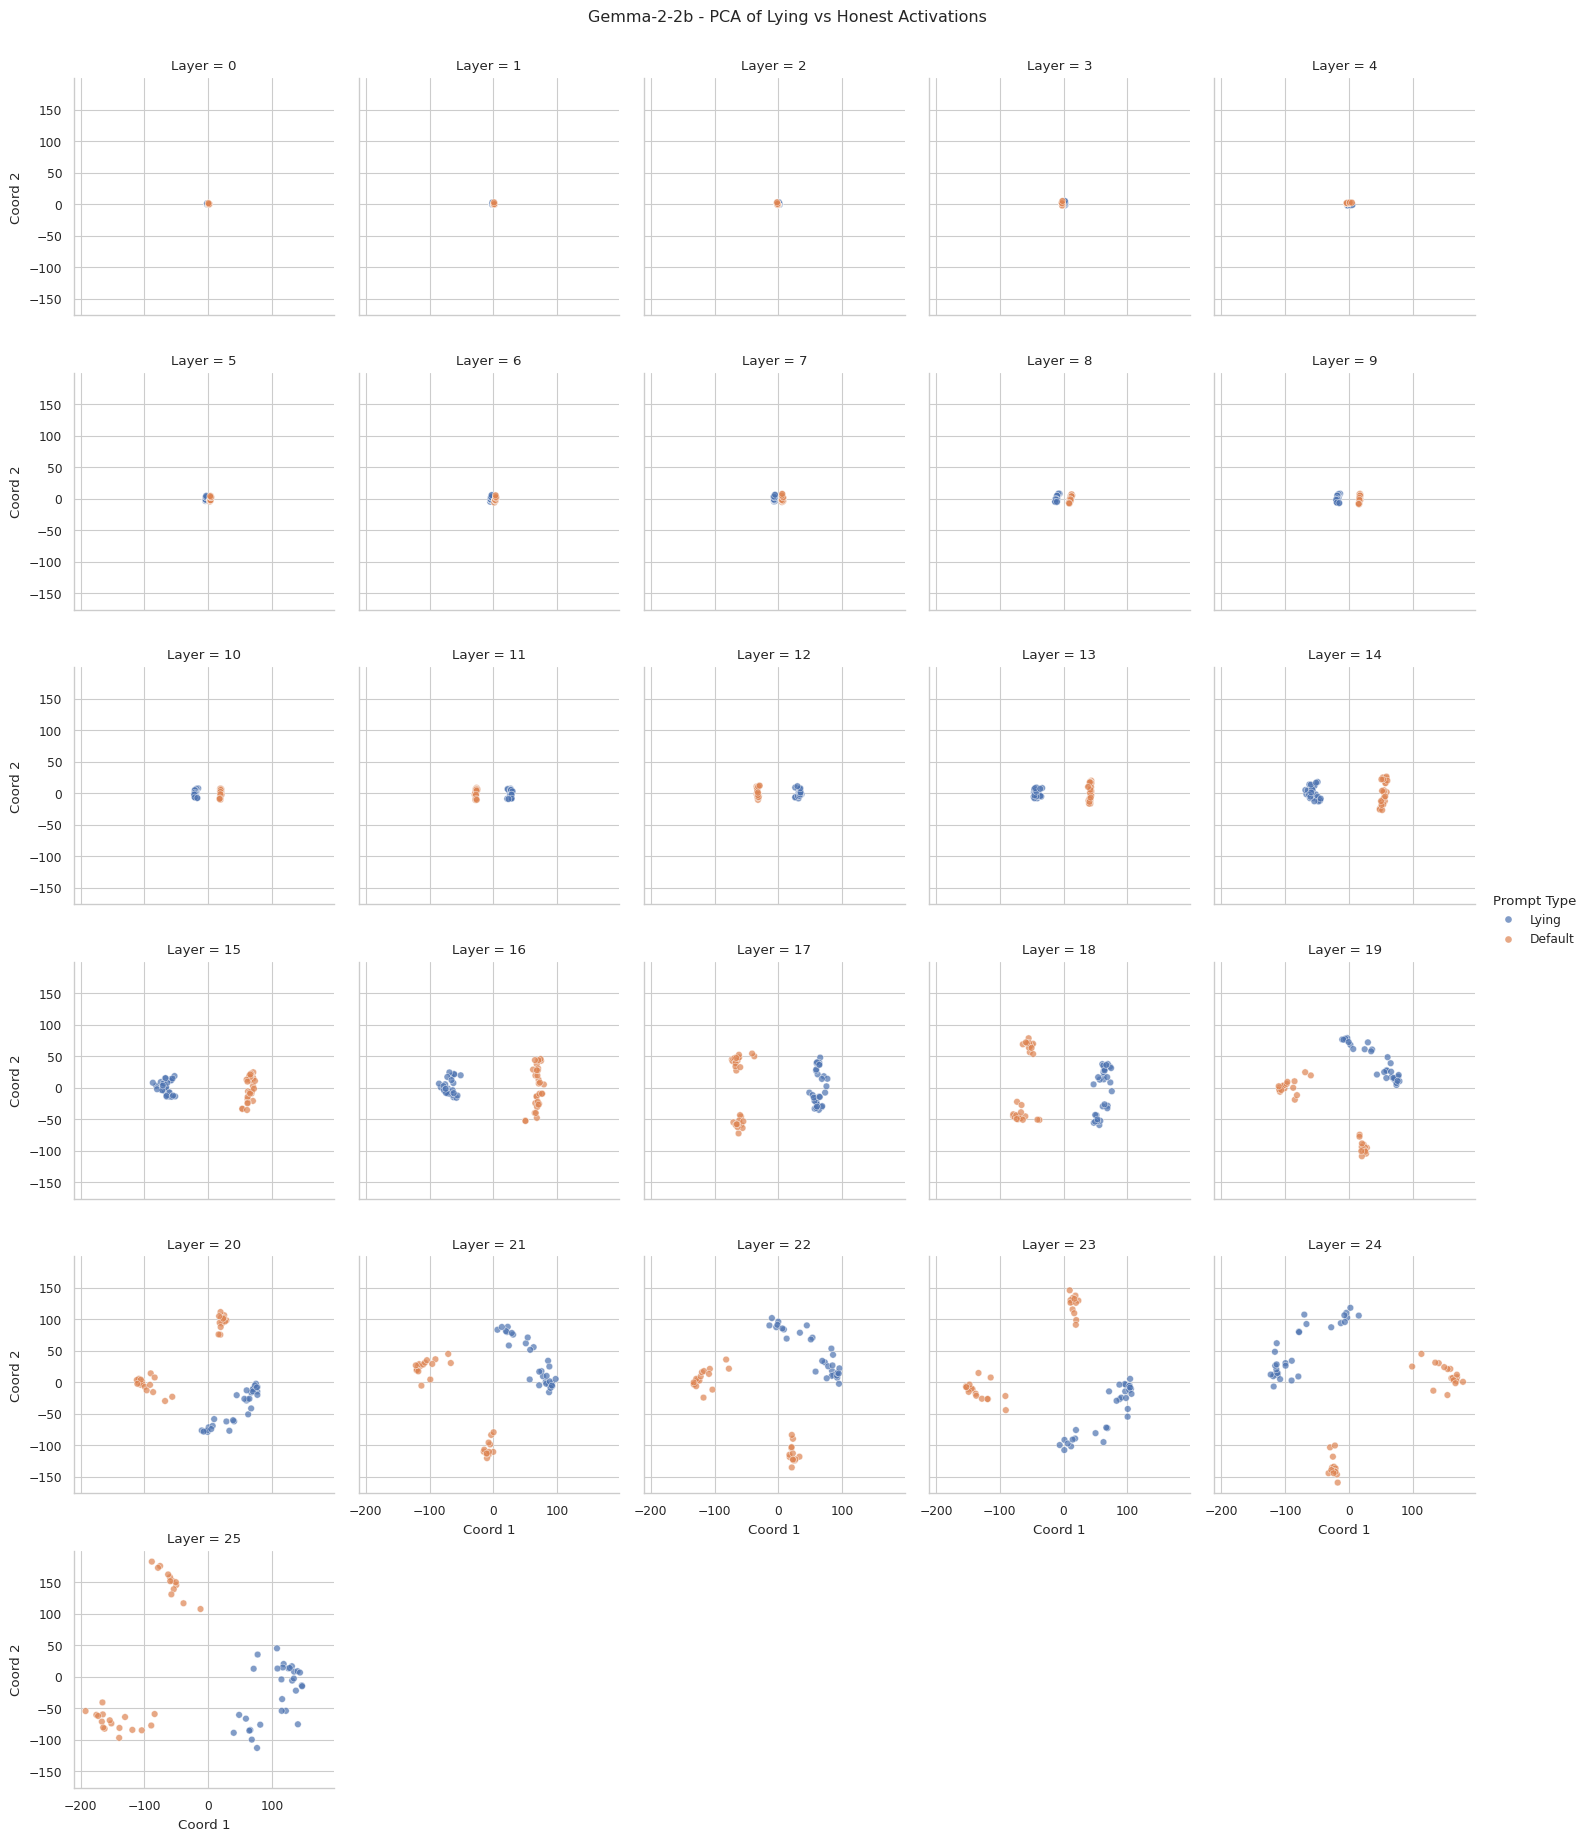

Calculating logit differences


Layers:   0%|          | 0/26 [00:00<?, ?it/s]

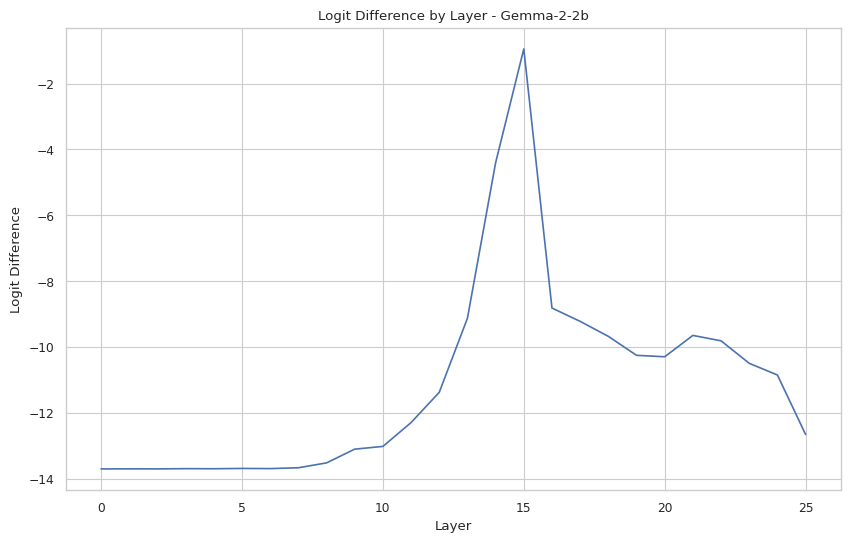

Analyzing lying accuracies


KeyError: 'Column not found: Judgement'

In [10]:
# Run analyses for Gemma-2-2b model
analyze_model(
    model=gemma_2_2b_it,
    model_name="Gemma-2-2b",
    easy_mcq=easy_mcq,
    easy_train=easy_train,
    easy_test=easy_test,
    hard_mcq=hard_mcq,
    hard_train=hard_train
)

# Run analyses for Gemma-2-9b model
analyze_model(
    model=gemma_2_9b_it,
    model_name="Gemma-2-9b",
    easy_mcq=easy_mcq,
    easy_train=easy_train,
    easy_test=easy_test,
    hard_mcq=hard_mcq,
    hard_train=hard_train
)
